In [57]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 10,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]


W = 5.0
from utils import newfig, fd

import utils as ut
import ei_open_loop as eol
import ei_unified as eu
import ei_jax as ej

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/testplots/"

In [58]:
nk = 20

bd = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)

p = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=None,
)

s0 = eu.solve_eq(
    bd,
    p,
    t=0.0,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)

mu0 = s0.mu
d0 = abs(s0.d)

tc = eu.critical_temperature(
    bd,
    p,
    tlo=1.0e-4,
    thi=2.0,
    tol=1.0e-7,
    nmax=100,
    prog=True,
)

print("Delta_0 =", d0)
print("T_c     =", tc)
print("mu0     =", mu0)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Delta_0 = 1.3438528051317822
T_c     = 0.6195541953906416
mu0     = 2.452325281248757


In [59]:
nt = 100

tn = np.linspace(0.03, 2.0, nt)
t1a = tn * tc
t2a = tn * tc

mua = np.empty(nt)
sea = []

de = s0.d
me = s0.m

for q in tqdm(range(nt), desc="Equilibrium references"):
    sq = eu.solve_eq(
        bd,
        p,
        t=t1a[q],
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    mua[q] = sq.mu
    sea.append(sq)

    de = sq.d
    me = sq.m

print(mua)
mu_B = np.mean(mua[: -len(mua) // 2])

Equilibrium references: 100%|██████████| 100/100 [00:57<00:00,  1.73it/s]

[1.80568002 1.37676043 1.30316938 1.3156731  1.32789621 1.33992406
 1.35180943 1.36357874 1.37524258 1.38680155 1.39824956 1.40957613
 1.42076812 1.43181111 1.44269055 1.45339259 1.46390465 1.47421575
 1.48431669 1.49420005 1.50386017 1.51329299 1.52249594 1.53146775
 1.5402083  1.54871849 1.55700008 1.56505552 1.57288793 1.5805009
 1.58789844 1.59508491 1.60206492 1.60884331 1.61542504 1.62181521
 1.62801895 1.63404144 1.63988788 1.64556341 1.65107315 1.65642216
 1.66161542 1.66665781 1.67155412 1.67630905 1.68092717 1.68541292
 1.68977067 1.69640624 1.70996253 1.7234183  1.73676194 1.74998846
 1.76309328 1.77607218 1.78892133 1.80163722 1.81421667 1.8266568
 1.83895501 1.851109   1.86311669 1.87497623 1.88668601 1.89824462
 1.90965081 1.92090352 1.93200185 1.94294503 1.95373244 1.96436355
 1.97483799 1.98515543 1.99531569 2.00531864 2.01516424 2.02485252
 2.03438359 2.04375761 2.05297481 2.06203549 2.07094    2.07968873
 2.08828217 2.09672084 2.10500533 2.11313628 2.12111442 2.128940

In [60]:
de = s0.d
me = s0.m

wc = np.inf
# wc=5.0

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = s0.d
me = s0.m

for j in tqdm(range(nt), desc="T2 rows"):
    t2 = t2a[j]

    se = eu.solve_eq(
        bd,
        p,
        t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    de = se.d
    me = se.m

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1 cols",
        leave=False,
    ):
        t1 = t1a[i]

        kaa = 0.3
        kab = 0.6
        kbb = 0.3

        bs = (
            ej.gam_db(
                t1, kap=(kaa, kab, kbb), wc=wc, mu=mu_B, name="bath 1", rate=ej.rate_product
            ),
            ej.gam_db(
                t2, kap=(kaa, kab, kbb), wc=wc, mu=mu_B, name="bath 2", rate=ej.rate_product
            ),
        )

        so = ej.solve_open(
            bd,
            p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.8,
            td=0.3,
            tm=0.3,
            tol=1.0e-4,
            nmax=20000,
            chk=20,
            prog=False,
        )

        ds = 1.0 * d0

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2 rows: 100%|██████████| 100/100 [01:30<00:00,  1.10it/s]


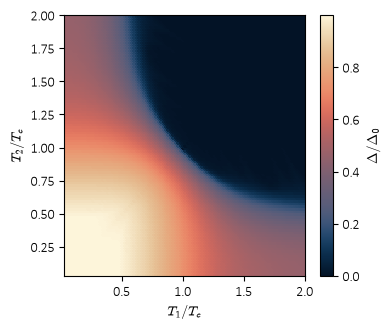

Converged: 10000 / 10000
Largest residual: 9.999796748161316e-05
Largest iteration count: 1060


In [61]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
plt.show()

print("Converged:", np.count_nonzero(ok), "/", ok.size)
print("Largest residual:", np.nanmax(er))
print("Largest iteration count:", np.max(it))

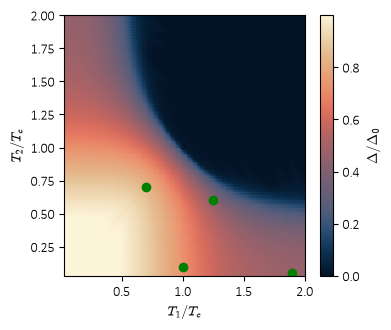

In [ ]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)
ax.scatter(0.7, 0.7, color="green")
ax.scatter(1.25, 0.6, color="green")
ax.scatter(1., 0.1, color="green")
ax.scatter(1.9, 0.05, color="green")

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig(OUT + "phase_diag_b3.pdf")

plt.show()

In [65]:
import json
from pathlib import Path
from datetime import datetime, timezone

from scipy.interpolate import RegularGridInterpolator


def point_report(
    x1,
    x2,
    tc0,
    folder=None,
    out=None,
    nk=100,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
    vv=5.0,
    nf=1.0,
    uh=None,
    kap=(0.3, 0.6, 0.3),
    wc=np.inf,
    dseed=None,
    mseed=None,
    dt=0.8,
    td=0.3,
    tm=0.3,
    tol=1.0e-4,
    nmax=20000,
    chk=20,
    mode="dense",
    block=512,
    ns=240,
    show=True,
):
    if out is None:
        out = OUT

    if folder is None:
        a = f"{x1:.3f}".replace(".", "p")
        b = f"{x2:.3f}".replace(".", "p")
        folder = f"point_t1_{a}_t2_{b}"

    root = Path(out) / folder
    pdir = root / "plots"

    root.mkdir(parents=True, exist_ok=True)
    pdir.mkdir(parents=True, exist_ok=True)

    bd = eu.tb_2d(
        nk=nk,
        gap=gap,
        ta=ta,
        tb=tb,
    )

    p = eu.MFPars(
        v=vv,
        n=nf,
        uh=uh,
    )

    s0 = eu.solve_eq(
        bd,
        p,
        t=0.0,
        d=1.0,
        m=0.0,
        mix=(0.15, 0.15),
        tol=1.0e-10,
        nmax=20000,
        chk=20,
        prog=True,
    )

    d0 = abs(s0.d)
    mu0 = s0.mu

    t1 = x1 * tc0
    t2 = x2 * tc0
    ts = min(t1, t2)

    se = eu.solve_eq(
        bd,
        p,
        t=ts,
        d=max(d0, 1.0e-6),
        m=s0.m,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=True,
    )

    if dseed is None:
        di = max(abs(se.d), d0)
    else:
        di = float(dseed)

    if mseed is None:
        mi = float(se.m)
    else:
        mi = float(mseed)

    bs = (
        ej.gam_db(
            t1,
            kap=kap,
            wc=wc,
            mu=mu_B,
            name="bath 1",
            rate=ej.rate_product,
        ),
        ej.gam_db(
            t2,
            kap=kap,
            wc=wc,
            mu=mu_B,
            name="bath 2",
            rate=ej.rate_product,
        ),
    )

    so = ej.solve_open(
        bd,
        p,
        se.n.copy(),
        bs,
        d=di,
        m=mi,
        dt=dt,
        td=td,
        tm=tm,
        tol=tol,
        nmax=nmax,
        chk=chk,
        prog=True,
        mode=mode,
        block=block,
    )

    st = ej.mf_state(
        bd,
        p,
        d=so.d,
        m=so.m,
    )

    nq = np.asarray(so.n)
    eq = np.asarray(st.e)

    ug = np.asarray(st.u).reshape(nk, nk)
    vg = np.asarray(st.v).reshape(nk, nk)

    ag = nq[0].reshape(nk, nk)
    bg = nq[1].reshape(nk, nk)

    oa, ob = ej.band_occ(
        st,
        so.n,
    )

    oa = np.asarray(oa).reshape(nk, nk)
    ob = np.asarray(ob).reshape(nk, nk)

    epg = eq[0].reshape(nk, nk)
    emg = eq[1].reshape(nk, nk)

    hag = np.asarray(st.eah).reshape(nk, nk)
    hbg = np.asarray(st.ebh).reshape(nk, nk)

    eag = np.asarray(bd.ea).reshape(nk, nk)
    ebg = np.asarray(bd.eb).reshape(nk, nk)

    ka = np.linspace(
        -np.pi,
        np.pi,
        nk,
        endpoint=False,
    )

    kx, ky = np.meshgrid(
        ka,
        ka,
        indexing="ij",
    )

    ke = np.concatenate(
        (
            ka,
            np.array([np.pi]),
        )
    )

    q = np.linspace(
        0.0,
        1.0,
        ns,
        endpoint=False,
    )

    p1 = np.column_stack(
        (
            np.pi * q,
            np.zeros_like(q),
        )
    )

    p2 = np.column_stack(
        (
            np.full_like(q, np.pi),
            np.pi * q,
        )
    )

    p3 = np.column_stack(
        (
            np.pi * (1.0 - q),
            np.pi * (1.0 - q),
        )
    )

    kp = np.vstack(
        (
            p1,
            p2,
            p3,
            np.array([[0.0, 0.0]]),
        )
    )

    dk = np.diff(kp, axis=0)
    dl = np.sqrt(np.sum(dk * dk, axis=1))

    sp = np.concatenate(
        (
            np.array([0.0]),
            np.cumsum(dl),
        )
    )

    ix = np.array(
        [
            0,
            ns,
            2 * ns,
            3 * ns,
        ]
    )

    sx = sp[ix]

    def per(z):
        ze = np.pad(
            z,
            ((0, 1), (0, 1)),
            mode="wrap",
        )

        fn = RegularGridInterpolator(
            (ke, ke),
            ze,
            method="linear",
            bounds_error=False,
        )

        return fn(kp)

    epp = per(epg)
    emp = per(emg)

    hap = per(hag)
    hbp = per(hbg)

    ap = per(ag)
    bp = per(bg)

    oap = per(oa)
    obp = per(ob)

    up = per(ug)
    vp = per(vg)

    xl = [
        r"$\Gamma$",
        r"$X$",
        r"$M$",
        r"$\Gamma$",
    ]

    es = abs(ta)

    def save_fig(fig, name):
        fig.savefig(
            pdir / f"{name}.pdf",
            bbox_inches="tight",
        )

        if show:
            plt.show()

        plt.close(fig)

    def add_path_lines(ax):
        ax.axvline(
            sx[1],
            color="0.5",
            lw=0.7,
            alpha=0.5,
        )

        ax.axvline(
            sx[2],
            color="0.5",
            lw=0.7,
            alpha=0.5,
        )

        ax.set_xticks(sx, xl)
        ax.set_xlim(sp[0], sp[-1])

    def map_pair(
        z0,
        z1,
        l0,
        l1,
        name,
        vmin,
        vmax,
    ):
        h = 1.75

        fig, ax = plt.subplots(
            2,
            1,
            figsize=(5, h * 5),
        )

        zz = (z0, z1)
        ll = (l0, l1)

        for j in tqdm(
            range(2),
            desc=f"{name} maps",
            leave=False,
        ):
            im = ax[j].pcolormesh(
                kx,
                ky,
                zz[j],
                shading="auto",
                cmap=cmaps.bubblegum,
                vmin=vmin,
                vmax=vmax,
            )

            im.set_edgecolor("face")

            cbar = fig.colorbar(
                im,
                ax=ax[j],
            )

            cbar.set_label(
                ll[j],
                rotation=90,
                labelpad=5,
            )

            ax[j].text(
                0.04,
                0.94,
                ll[j],
                transform=ax[j].transAxes,
                ha="left",
                va="top",
            )

            ax[j].set_xlabel(r"$k_x$")
            ax[j].set_ylabel(r"$k_y$")

            ax[j].set_xlim(
                ka[0],
                ka[-1],
            )

            ax[j].set_ylim(
                ka[0],
                ka[-1],
            )

            ax[j].set_aspect("equal")

        plt.tight_layout()
        save_fig(fig, name)

    def path_pair(
        z0,
        z1,
        l0,
        l1,
        yl,
        name,
    ):
        h = 0.65

        fig, ax = plt.subplots(figsize=(5, h * 5))

        ax.plot(
            sp,
            z0,
            color=set1_list[0],
            lw=1.5,
            label=l0,
        )

        ax.plot(
            sp,
            z1,
            color=set1_list[1],
            lw=1.5,
            label=l1,
        )

        add_path_lines(ax)

        ax.set_xlabel(r"$\mathbf{k}$")
        ax.set_ylabel(yl)
        ax.grid(alpha=0.3)

        ax.legend()

        plt.tight_layout()
        save_fig(fig, name)

    h = 1.25

    fig, ax = plt.subplots(
        2,
        1,
        figsize=(5, h * 5),
        sharex=True,
    )

    ax[0].plot(
        sp,
        epp / es,
        color=set1_list[0],
        lw=1.5,
        label=r"$E_{\alpha\mathbf{k}}$",
    )

    ax[0].plot(
        sp,
        emp / es,
        color=set1_list[1],
        lw=1.5,
        label=r"$E_{\beta\mathbf{k}}$",
    )

    ax[0].plot(
        sp,
        hap / es,
        color=set1_list[2],
        lw=1.0,
        ls="--",
        label=r"$\epsilon^H_{a\mathbf{k}}$",
    )

    ax[0].plot(
        sp,
        hbp / es,
        color=set1_list[3],
        lw=1.0,
        ls="--",
        label=r"$\epsilon^H_{b\mathbf{k}}$",
    )

    ax[0].axvline(
        sx[1],
        color="0.5",
        lw=0.7,
        alpha=0.5,
    )

    ax[0].axvline(
        sx[2],
        color="0.5",
        lw=0.7,
        alpha=0.5,
    )

    ax[0].set_xlim(sp[0], sp[-1])
    ax[0].set_ylabel(r"$E/|t_a|$")
    ax[0].grid(alpha=0.3)

    ax[0].text(
        0.03,
        0.05,
        (rf"$T_1={x1:.3f}T_c$" "\n" rf"$T_2={x2:.3f}T_c$"),
        transform=ax[0].transAxes,
        ha="left",
        va="bottom",
    )

    ax[0].legend()

    ax[1].plot(
        sp,
        up,
        color=set1_list[0],
        lw=1.5,
        label=r"$u_{\mathbf{k}}$",
    )

    ax[1].plot(
        sp,
        vp,
        color=set1_list[1],
        lw=1.5,
        label=r"$v_{\mathbf{k}}$",
    )

    add_path_lines(ax[1])

    ax[1].set_xlabel(r"$\mathbf{k}$")
    ax[1].set_ylabel(r"$u_{\mathbf{k}},v_{\mathbf{k}}$")
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    save_fig(
        fig,
        "dispersion_uv_path",
    )

    map_pair(
        ag,
        bg,
        r"$n_{\alpha\mathbf{k}}$",
        r"$n_{\beta\mathbf{k}}$",
        "occ_qp_maps",
        0.0,
        1.0,
    )

    path_pair(
        ap,
        bp,
        r"$n_{\alpha\mathbf{k}}$",
        r"$n_{\beta\mathbf{k}}$",
        r"$n_{\lambda\mathbf{k}}$",
        "occ_qp_path",
    )

    map_pair(
        oa,
        ob,
        r"$n_{a\mathbf{k}}$",
        r"$n_{b\mathbf{k}}$",
        "occ_ab_maps",
        0.0,
        1.0,
    )

    path_pair(
        oap,
        obp,
        r"$n_{a\mathbf{k}}$",
        r"$n_{b\mathbf{k}}$",
        r"$n_{r\mathbf{k}}$",
        "occ_ab_path",
    )

    uv0 = min(
        0.0,
        float(np.min(ug)),
        float(np.min(vg)),
    )

    uv1 = max(
        1.0,
        float(np.max(ug)),
        float(np.max(vg)),
    )

    map_pair(
        ug,
        vg,
        r"$u_{\mathbf{k}}$",
        r"$v_{\mathbf{k}}$",
        "uv_maps",
        uv0,
        uv1,
    )

    data_file = root / "diagnostics.npz"

    np.savez_compressed(
        data_file,
        kx=kx,
        ky=ky,
        w=np.asarray(bd.w),
        ea_bare=eag,
        eb_bare=ebg,
        ea_hartree=hag,
        eb_hartree=hbg,
        e_alpha=epg,
        e_beta=emg,
        n_alpha=ag,
        n_beta=bg,
        n_a=oa,
        n_b=ob,
        u=ug,
        v=vg,
        path_s=sp,
        path_kx=kp[:, 0],
        path_ky=kp[:, 1],
        path_e_alpha=epp,
        path_e_beta=emp,
        path_ea_hartree=hap,
        path_eb_hartree=hbp,
        path_n_alpha=ap,
        path_n_beta=bp,
        path_n_a=oap,
        path_n_b=obp,
        path_u=up,
        path_v=vp,
    )

    fill = np.sum(np.asarray(bd.w) * np.sum(nq, axis=0))

    wc_json = "inf" if np.isinf(wc) else float(wc)

    relax_time = getattr(
        so,
        "t",
        None,
    )

    if relax_time is not None:
        relax_time = float(relax_time)

    cfg = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "point": {
            "t1_over_tc": float(x1),
            "t2_over_tc": float(x2),
            "t1": float(t1),
            "t2": float(t2),
            "tc_reference": float(tc0),
        },
        "grid": {
            "nk": int(nk),
            "n_points": int(bd.size),
            "path_points_per_segment": int(ns),
            "path": "Gamma-X-M-Gamma",
        },
        "bands": {
            "gap": float(gap),
            "ta": float(ta),
            "tb": float(tb),
        },
        "mean_field": {
            "v": float(vv),
            "filling": float(nf),
            "uh": (None if uh is None else float(uh)),
        },
        "bath": {
            "rate": "ej.rate_db",
            "kap_aa": float(kap[0]),
            "kap_ab": float(kap[1]),
            "kap_bb": float(kap[2]),
            "wc": wc_json,
            "mu": 0.0,
            "orbital": None,
        },
        "solver": {
            "dt": float(dt),
            "td": float(td),
            "tm": float(tm),
            "tol": float(tol),
            "nmax": int(nmax),
            "chk": int(chk),
            "mode": str(mode),
            "block": int(block),
        },
        "seed": {
            "equilibrium_temperature": float(ts),
            "equilibrium_t_over_tc": float(ts / tc0),
            "equilibrium_d": float(se.d),
            "equilibrium_m": float(se.m),
            "equilibrium_mu": float(se.mu),
            "d_used": float(di),
            "m_used": float(mi),
        },
        "fine_reference": {
            "delta_0": float(d0),
            "mu_0": float(mu0),
        },
        "result": {
            "ok": bool(so.ok),
            "iterations": int(so.it),
            "error": float(so.err),
            "relax_time": relax_time,
            "d": float(so.d),
            "abs_d": float(abs(so.d)),
            "abs_d_over_delta_0": float(abs(so.d) / d0),
            "m": float(so.m),
            "filling": float(fill),
        },
        # "software": {
        #     "numpy": np.__version__,
        #     "jax": jax.__version__,
        #     "ei_unified": str(getattr(eu, "__file__", "")),
        #     "ei_jax": str(getattr(ej, "__file__", "")),
        # },
        # "files": {
        #     "data": "diagnostics.npz",
        #     "plot_directory": "plots",
        #     "plots": [
        #         "dispersion_uv_path",
        #         "occ_qp_maps",
        #         "occ_qp_path",
        #         "occ_ab_maps",
        #         "occ_ab_path",
        #         "uv_maps",
        #     ],
        # },
    }

    json_file = root / "params.json"

    with json_file.open(
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            cfg,
            f,
            indent=2,
            allow_nan=False,
        )

    print("Saved to:", root)
    print("Converged:", so.ok)
    print("Residual:", so.err)
    print("Delta / Delta_0:", abs(so.d) / d0)
    print("Filling:", fill)

    return {
        "bd": bd,
        "p": p,
        "sol": so,
        "state": st,
        "config": cfg,
        "root": root,
        "plots": pdir,
        "data": data_file,
        "json": json_file,
    }

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

Open EI JAX:   0%|          | 0/1000 [00:00<?, ?it/s]

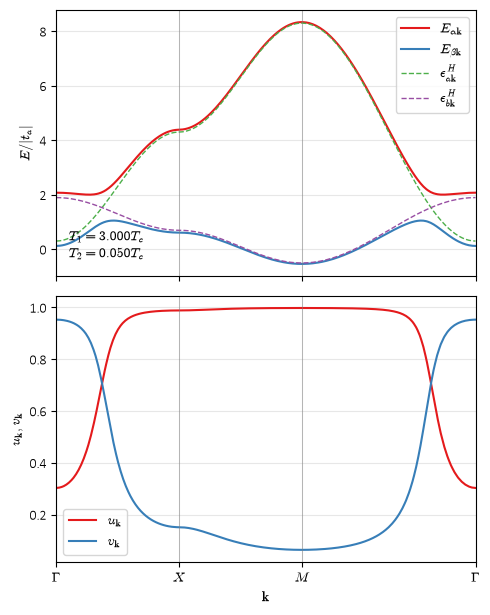

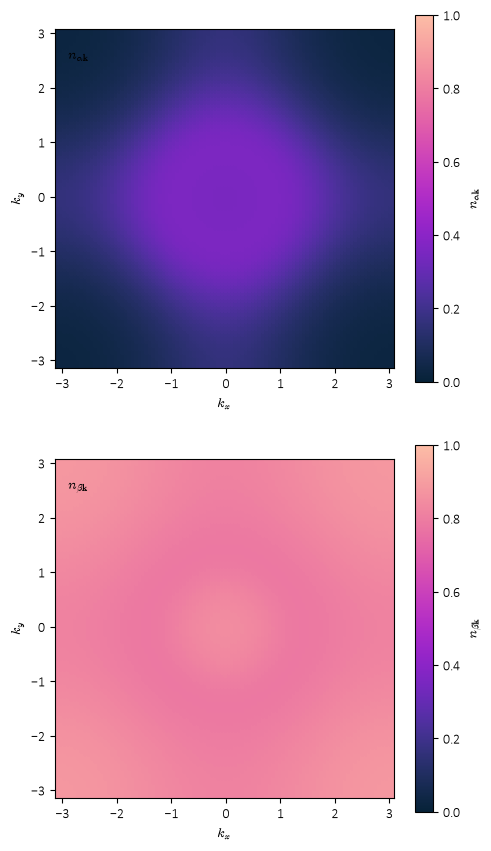

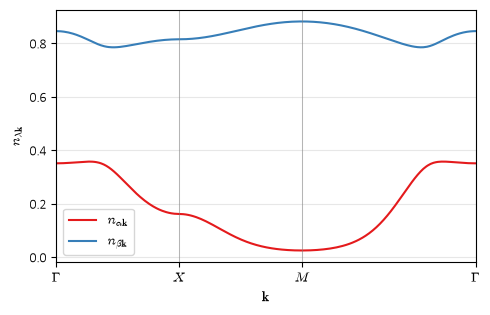

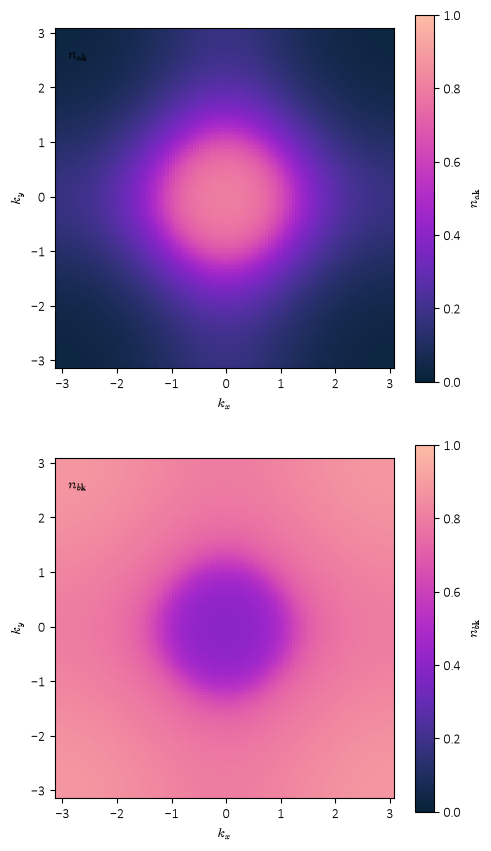

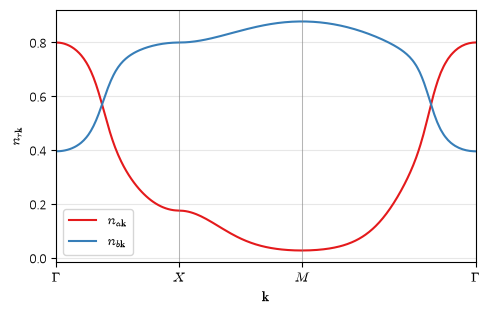

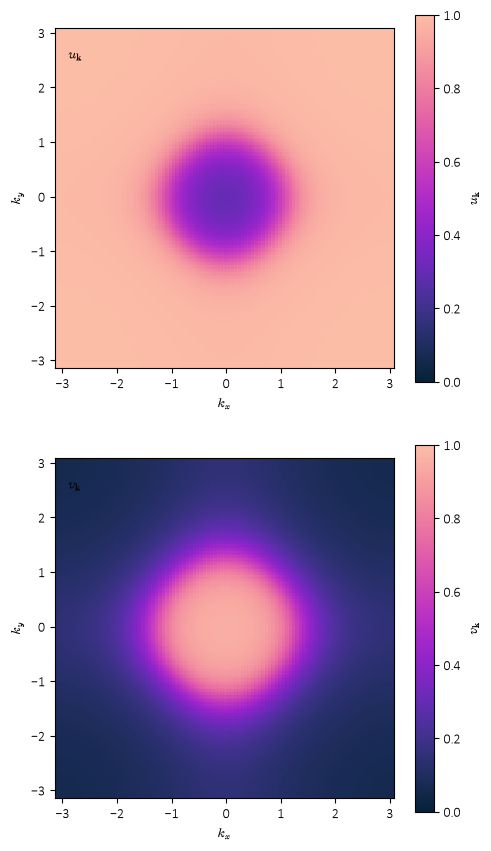

Saved to: /home/kzeleznikar/IJS-F1/Koda/EI_baths/testplots/b3_t1_3p00_t2_0p05
Converged: True
Residual: 3.516674041748047e-06
Delta / Delta_0: 0.4196730839842159
Filling: 0.9999999583601953


In [70]:
x1 = 3.0
x2 = 0.05

i0 = int(
    np.argmin(np.abs(tn - x1))
)

j0 = int(
    np.argmin(np.abs(tn - x2))
)

res = point_report(
    x1=x1,
    x2=x2,
    tc0=tc,
    folder="b3_t1_3p00_t2_0p05",
    out=OUT,
    nk=100,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
    vv=5.0,
    nf=1.0,
    uh=None,
    kap=(0.3, 0.6, 0.3),
    wc=np.inf,
    dseed=max(
        float(da[j0, i0]),
        d0,
    ),
    mseed=float(ma[j0, i0]),
    dt=0.8,
    td=0.3,
    tm=0.3,
    tol=1.0e-4,
    nmax=20000,
    chk=20,
    ns=240,
    show=True,
)

In [95]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

nk = 100

bd = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)

# Fixed T1 and increasing T2
x1 = 0.7
x2a = np.linspace(0.7, 1.7, 9)

t1 = x1 * tc

# Equilibrium reference at T1
se = eu.solve_eq(
    bd,
    p,
    t=t1,
    d=max(abs(s0.d), 1.0e-6),
    m=s0.m,
    mix=(0.15, 0.15),
    tol=1.0e-9,
    nmax=20000,
    chk=20,
    prog=True,
)

# Gamma-X-M-Gamma path
nk1 = int(round(np.sqrt(se.n.shape[1])))

c = nk1 // 2
q = np.arange(c + 1)

i1 = c - q
j1 = np.full_like(q, c)

i2 = np.zeros(c, dtype=int)
j2 = c - np.arange(1, c + 1)

i3 = np.arange(1, c + 1)
j3 = np.arange(1, c + 1)

ii = np.concatenate((i1, i2, i3))
jj = np.concatenate((j1, j2, j3))

s1 = np.linspace(0.0, np.pi, c + 1)
s2 = np.linspace(np.pi, 2.0 * np.pi, c + 1)[1:]
s3 = np.linspace(
    2.0 * np.pi,
    (2.0 + np.sqrt(2.0)) * np.pi,
    c + 1,
)[1:]

ks = np.concatenate((s1, s2, s3))

kt = [
    0.0,
    np.pi,
    2.0 * np.pi,
    (2.0 + np.sqrt(2.0)) * np.pi,
]

kl = [
    r"$\Gamma$",
    r"$X$",
    r"$M$",
    r"$\Gamma$",
]


def path(n):
    n = np.asarray(n)
    na = n[0].reshape(nk1, nk1)[ii, jj]
    nb = n[1].reshape(nk1, nk1)[ii, jj]
    return na, nb


# Equilibrium occupations
nea, neb = path(se.n)

# Bath parameters
kaa = 0.3
kab = 0.3
kbb = 0.3
wc = np.inf

# Output arrays
naa = np.empty((x2a.size, ks.size))
nba = np.empty_like(naa)
da1 = np.empty(x2a.size)
era = np.empty(x2a.size)
oka = np.empty(x2a.size, dtype=bool)

# Start from equilibrium at T1
n = se.n.copy()
d = se.d
m = se.m

bar = tqdm(x2a, desc="T2 sweep")

for q, x2 in enumerate(bar):
    t2 = x2 * tc

    bs = (
        ej.gam_db(
            t1,
            kap=(kaa, kab, kbb),
            wc=wc,
            mu=0.0,
            name="bath 1",
            rate=ej.rate_db,
        ),
        ej.gam_db(
            t2,
            kap=(kaa, kab, kbb),
            wc=wc,
            mu=0.0,
            name="bath 2",
            rate=ej.rate_db,
        ),
    )

    sp = ej.solve_open(
        bd,
        p,
        n,
        bs,
        d=d,
        m=m,
        dt=0.8,
        td=0.3,
        tm=0.3,
        tol=1.0e-5,
        nmax=20000,
        chk=20,
        prog=False,
    )

    naa[q], nba[q] = path(sp.n)
    da1[q] = abs(sp.d)
    era[q] = sp.err
    oka[q] = sp.ok

    # Continue from the previous T2 point
    n = sp.n.copy()
    d = sp.d
    m = sp.m

    bar.set_postfix(
        t2=f"{x2:.2f}",
        d=f"{abs(sp.d):.3e}",
        err=f"{sp.err:.2e}",
    )

print("All converged:", np.all(oka))
print("Largest error:", np.max(era))

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

T2 sweep:   0%|          | 0/9 [00:00<?, ?it/s]

All converged: True
Largest error: 9.585171937942505e-06


Plotting:   0%|          | 0/9 [00:00<?, ?it/s]

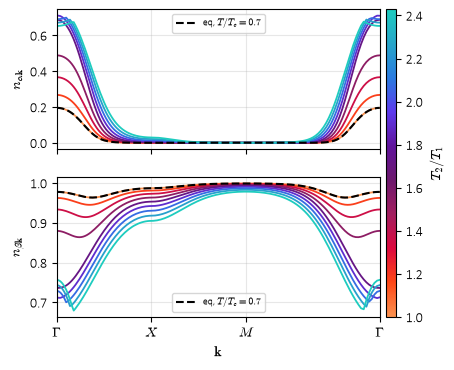

In [96]:
ra = x2a / x1

norm = Normalize(vmin=ra.min(), vmax=ra.max())
cm = bgr_custom
sm = ScalarMappable(norm=norm, cmap=cm)
sm.set_array([])

h = 1.15
fig, ax = plt.subplots(
    2,
    1,
    figsize=(1.2 * 3.47412, h * 3.47412),
    sharex=True,
)

for q in tqdm(range(x2a.size), desc="Plotting"):
    cl = cm(norm(ra[q]))

    ax[0].plot(
        ks,
        naa[q],
        color=cl,
        linewidth=1.3,
    )

    ax[1].plot(
        ks,
        nba[q],
        color=cl,
        linewidth=1.3,
    )

# Plot references last so that they remain visible
ax[0].plot(
    ks,
    nea,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=rf"eq, $T/T_c={x1:.1f}$",
)

ax[1].plot(
    ks,
    neb,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=rf"eq, $T/T_c={x1:.1f}$",
)

ax[0].set_ylabel(r"$n_{\alpha\mathbf{k}}$")
ax[1].set_ylabel(r"$n_{\beta\mathbf{k}}$")
ax[1].set_xlabel(r"$\mathbf{k}$")

for a in ax:
    a.set_xlim(ks[0], ks[-1])
    a.set_xticks(kt)
    a.set_xticklabels(kl)
    a.grid(alpha=0.3)
    a.legend(loc="best", fontsize=7)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Remove or comment out your previous cbar line:
# cbar = fig.colorbar(sm, ax=ax, pad=0.02)

# Create an inset axes attached to the right side of the subplot array
cax = inset_axes(
    ax[1],
    width="3%",  # Makes the colorbar thin
    height="220%",  # Adjusts height to span both subplots
    loc="lower left",
    bbox_to_anchor=(1.02, 0, 1, 1),
    bbox_transform=ax[1].transAxes,
    borderpad=0,
)

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"$T_2/T_1$", rotation=90, labelpad=5)

# plt.savefig(OUT+"nalpha_beta_b1.pdf", bbox_inches="tight")
plt.show()